<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

---

### ScalarImage

```python

def ScalarImage(
    args:VAR_POSITIONAL, kwargs:VAR_KEYWORD
):


```

*Image whose pixel values represent scalars.*

Example:

    >>> import torch
    >>> import torchio as tio
    >>> # Loading from a file
    >>> t1_image = tio.ScalarImage('t1.nii.gz')
    >>> dmri = tio.ScalarImage(tensor=torch.rand(32, 128, 128, 88))
    >>> image = tio.ScalarImage('safe_image.nrrd', check_nans=False)
    >>> data, affine = image.data, image.affine
    >>> affine.shape
    (4, 4)
    >>> image.data is image[tio.DATA]
    True
    >>> image.data is image.tensor
    True
    >>> type(image.data)
    torch.Tensor

See :class:`~torchio.Image` for more information.

## Image Writers

In [0]:
#| echo: false
#| output: asis
show_doc(write_image)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L64){target="_blank" style="float:right; font-size:smaller"}

### write_image

```python

def write_image(
    data, file_path, dimension_order:str='TCZYX'
):


```

*Writes an image to a file.*

:param data: Image data (numpy array, tensor, or AICSImage)
:param file_path: Path to save the image
:param format: Format to save the image in (default is png)

In [ ]:
# Example usage:
numpy_array = np.random.rand(3, 100, 100)
write_image(numpy_array, './data_examples/output_from_numpy.tiff')

metatensor = torch.rand(3, 100, 100)
write_image(metatensor, './data_examples/output_from_tensor.tiff')

aics_image = AICSImage('./data_examples/example_tiff.tiff')
write_image(aics_image, './data_examples/output_from_tiff.png')

Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0


Image successfully saved to ./data_examples/output_from_numpy.tiff
Image successfully saved to ./data_examples/output_from_tensor.tiff
Image successfully saved to ./data_examples/output_from_tiff.png


In [ ]:
#| echo: false
#| output: asis
show_doc(SaveImage)

---

### SaveImage

```python

def SaveImage(
    output_dir:PathLike='./', output_postfix:str='trans', output_ext:str='.nii.gz',
    output_dtype:DtypeLike | None=float32, resample:bool=False, mode:str='nearest', padding_mode:str=border,
    scale:int | None=None, dtype:DtypeLike=float64, squeeze_end_dims:bool=True, data_root_dir:PathLike='',
    separate_folder:bool=True, print_log:bool=True, output_format:str='',
    writer:type[image_writer.ImageWriter] | str | None=None, channel_dim:int | None=0,
    output_name_formatter:Callable[[dict, Transform], dict] | None=None, folder_layout:FolderLayoutBase | None=None,
    savepath_in_metadict:bool=False
)->None:


```

*Save the image (in the form of torch tensor or numpy ndarray) and metadata dictionary into files.*

The name of saved file will be `{input_image_name}_{output_postfix}{output_ext}`,
where the `input_image_name` is extracted from the provided metadata dictionary.
If no metadata provided, a running index starting from 0 will be used as the filename prefix.

Args:
    output_dir: output image directory.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_postfix: a string appended to all output file names, default to `trans`.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_ext: output file extension name.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_dtype: data type (if not None) for saving data. Defaults to ``np.float32``.
    resample: whether to resample image (if needed) before saving the data array,
        based on the ``"spatial_shape"`` (and ``"original_affine"``) from metadata.
    mode: This option is used when ``resample=True``. Defaults to ``"nearest"``.
        Depending on the writers, the possible options are

        - {``"bilinear"``, ``"nearest"``, ``"bicubic"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
        - {``"nearest"``, ``"linear"``, ``"bilinear"``, ``"bicubic"``, ``"trilinear"``, ``"area"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#interpolate

    padding_mode: This option is used when ``resample = True``. Defaults to ``"border"``.
        Possible options are {``"zeros"``, ``"border"``, ``"reflection"``}
        See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
    scale: {``255``, ``65535``} postprocess data by clipping to [0, 1] and scaling
        [0, 255] (``uint8``) or [0, 65535] (``uint16``). Default is ``None`` (no scaling).
    dtype: data type during resampling computation. Defaults to ``np.float64`` for best precision.
        if ``None``, use the data type of input data. To set the output data type, use ``output_dtype``.
    squeeze_end_dims: if ``True``, any trailing singleton dimensions will be removed (after the channel
        has been moved to the end). So if input is (C,H,W,D), this will be altered to (H,W,D,C), and
        then if C==1, it will be saved as (H,W,D). If D is also 1, it will be saved as (H,W). If ``False``,
        image will always be saved as (H,W,D,C).
    data_root_dir: if not empty, it specifies the beginning parts of the input file's
        absolute path. It's used to compute ``input_file_rel_path``, the relative path to the file from
        ``data_root_dir`` to preserve folder structure when saving in case there are files in different
        folders with the same file names. For example, with the following inputs:

        - input_file_name: ``/foo/bar/test1/image.nii``
        - output_postfix: ``seg``
        - output_ext: ``.nii.gz``
        - output_dir: ``/output``
        - data_root_dir: ``/foo/bar``

        The output will be: ``/output/test1/image/image_seg.nii.gz``

        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    separate_folder: whether to save every file in a separate folder. For example: for the input filename
        ``image.nii``, postfix ``seg`` and ``folder_path`` ``output``, if ``separate_folder=True``, it will be
        saved as: ``output/image/image_seg.nii``, if ``False``, saving as ``output/image_seg.nii``.
        Default to ``True``.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    print_log: whether to print logs when saving. Default to ``True``.
    output_format: an optional string of filename extension to specify the output image writer.
        see also: ``monai.data.image_writer.SUPPORTED_WRITERS``.
    writer: a customised ``monai.data.ImageWriter`` subclass to save data arrays.
        if ``None``, use the default writer from ``monai.data.image_writer`` according to ``output_ext``.
        if it's a string, it's treated as a class name or dotted path (such as ``"monai.data.ITKWriter"``);
        the supported built-in writer classes are ``"NibabelWriter"``, ``"ITKWriter"``, ``"PILWriter"``.
    channel_dim: the index of the channel dimension. Default to ``0``.
        ``None`` to indicate no channel dimension.
    output_name_formatter: a callable function (returning a kwargs dict) to format the output file name.
        If using a custom ``monai.data.FolderLayoutBase`` class in ``folder_layout``, consider providing
        your own formatter.
        see also: :py:func:`monai.data.folder_layout.default_name_formatter`.
    folder_layout: A customized ``monai.data.FolderLayoutBase`` subclass to define file naming schemes.
        if ``None``, uses the default ``FolderLayout``.
    savepath_in_metadict: if ``True``, adds a key ``"saved_to"`` to the metadata, which contains the path
        to where the input image has been saved.

## Image Loaders

It uses helper functions to load and preprocess biological images.

### Utils

In [0]:
#| echo: false
#| output: asis
show_doc(tiff2torch)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L93){target="_blank" style="float:right; font-size:smaller"}

### tiff2torch

```python

def tiff2torch(
    file_path:str
):


```

*Load tiff into pytorch tensor*

In [0]:
#| echo: false
#| output: asis
show_doc(string2dict)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L103){target="_blank" style="float:right; font-size:smaller"}

### string2dict

```python

def string2dict(
    s:str
)->dict:


```

*Parse layout strings with:*
    - sizes: C2
    - slices: Y[100:200]
    - steps:  Y[100:200:2]

Returns:
    dict[str, int | slice | None]

In [0]:
#| echo: false
#| output: asis
show_doc(split_path)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L152){target="_blank" style="float:right; font-size:smaller"}

### split_path

```python

def split_path(
    file_path, # The path to the file to split
    exts:(<class 'fastcore.foundation.L'>, <class 'list'>)=['.ome.tiff', '.tiff', '.tif', '.png'], # List of filename extensions
):


```

In [ ]:
split_path('./data_examples/example_ome_tiff.ome.tiff/X[10:20:2]Z0')

('./data_examples/example_ome_tiff.ome.tiff', {'X': slice(10, 20, 2), 'Z': 0})

In [0]:
#| echo: false
#| output: asis
show_doc(is_ome_tiff)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L167){target="_blank" style="float:right; font-size:smaller"}

### is_ome_tiff

```python

def is_ome_tiff(
    path:Path
)->bool:


```

In [ ]:
test_eq(is_ome_tiff(Path('./data_examples/example_ome_tiff.ome.tiff')), True)
test_eq(is_ome_tiff(Path('./data_examples/example_ome.tiff')), False)

In [0]:
#| echo: false
#| output: asis
show_doc(get_aics_metadata)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L221){target="_blank" style="float:right; font-size:smaller"}

### get_aics_metadata

```python

def get_aics_metadata(
    obj, skip:NoneType=None
):


```

*Return expanded metadata dictionary from an AICSImage object.*

In [0]:
#| echo: false
#| output: asis
show_doc(extract_formats)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L261){target="_blank" style="float:right; font-size:smaller"}

### extract_formats

```python

def extract_formats(
    filenames:collections.abc.Sequence[str] | str
)->list:


```

*Extract file format(s) from one or multiple filenames.*

Supports:
    - standard extensions (.nii.gz, .png, .npz)
    - HDF5 internal paths (.hdf5/... or .h5/...)

Args:
    filenames: single path or sequence of paths.

Returns:
    List of format strings in uppercase (without dots),
    or None if no suffix is found.

### BioIO Formats

In [0]:
#| echo: false
#| output: asis
show_doc(bioio_loader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L343){target="_blank" style="float:right; font-size:smaller"}

### bioio_loader

```python

def bioio_loader(
    ind_dict:NoneType=None, # Dictionary indicating the channels to load
    loader:NoneType=None, # Optional custom reader to use for loading the image
    channels:str='CZYX', # The desired channel order for the output data
    kwargs:VAR_KEYWORD
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

In [ ]:
file_path = 'data_examples/cameraman_noisy.jpg'
test_img, meta, affine = bioio_loader({'Y': slice(0,10)}, channels="CZYX")(file_path)
test_eq(test_img.shape, (1, 1, 10, 225))

In [ ]:
a = MetaTensor(x=test_img, affine=affine, meta=meta)

In [ ]:
test_eq(a.affine, Tensor(np.eye(4)))

In [ ]:
a.detach().cpu().numpy()

array([[[[161, 140, 154, ..., 110, 159, 148],
         [132, 153, 160, ..., 101, 147, 158],
         [166, 148, 171, ..., 152, 141, 151],
         ...,
         [133, 133, 154, ..., 143, 154, 133],
         [163, 154, 146, ..., 152, 135, 166],
         [163, 176, 177, ..., 167, 151, 143]]]],
      shape=(1, 1, 10, 225), dtype=uint8)

In [ ]:
a.meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 1, 'Y': 225, 'X': 225, 'S': 3},
 'dtype': 'uint8',
 'metadata': {'jfif': 257,
  'jfif_version': [1, 1],
  'jfif_unit': 0,
  'jfif_density': [1, 1],
  'mode': 'RGB',
  'shape': [225, 225]},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'extension': 'jpg', 'imageio_read_mode': '?'},
 'resolution_level_dims': {0: [225, 225, 3]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 1, 225, 225, 3],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'YXS',
  'image_size_c': None,
  'image_size_t': None,
  'image_size_x': 225,
  'image_size_y': 225,
  'image_size_z': None,
  'imaged_b

### Hierarchical Data Format

In [0]:
#| echo: false
#| output: asis
show_doc(split_hdf_path)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L394){target="_blank" style="float:right; font-size:smaller"}

### split_hdf_path

```python

def split_hdf_path(
    file_path, # The path to the HDF5 file to split
    hdf5_exts:(<class 'fastcore.foundation.L'>, <class 'list'>)=['.h5', '.hdf5'], # List of filename extensions
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(hdf5_loader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L411){target="_blank" style="float:right; font-size:smaller"}

### hdf5_loader

```python

def hdf5_loader(
    dataset:Optional=None, # The dataset to load
    patch:Optional=None, # The patch to load from the dataset
    hdf5_exts:List=['.h5', '.hdf5'], # List of filename extensions
    channels:str='CYX', # The desired channel layout for the output data
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

Images can be loaded by explicitly writing dataset name and path number...

In [ ]:
from bioMONAI.visualize import show_image

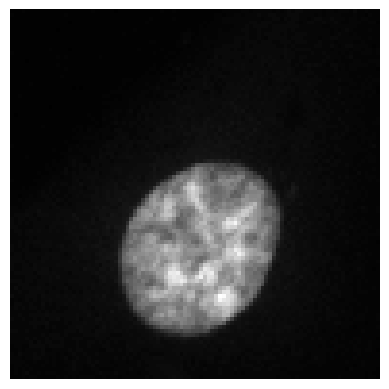

In [ ]:
file_path = './data_examples/0450_1.hdf5'
dataset_name='clean'
patch_num='10'

im , meta, _ = hdf5_loader(dataset=dataset_name, patch=patch_num)(file_path)
show_image(im[0])

In [ ]:
im.shape

(1, 96, 96)

... or enconding them in the path, where datasets are subfolders and patches the image files. The latter being compatible with [`image_reader`](https://deepCLEM.github.io/bioMONAI/io.html#image_reader) syntaxis.

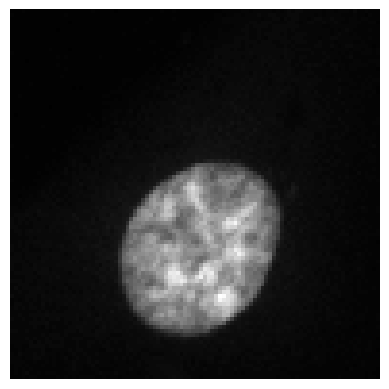

In [ ]:
f = file_path + '/' + dataset_name + '/' + str(patch_num)
im , meta, _ = hdf5_loader()(f)
show_image(im[0])

### Preprocessing

Define classes to store Metadata

In [ ]:
a.meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 1, 'Y': 225, 'X': 225, 'S': 3},
 'dtype': 'uint8',
 'metadata': {'jfif': 257,
  'jfif_version': [1, 1],
  'jfif_unit': 0,
  'jfif_density': [1, 1],
  'mode': 'RGB',
  'shape': [225, 225]},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'extension': 'jpg', 'imageio_read_mode': '?'},
 'resolution_level_dims': {0: [225, 225, 3]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 1, 225, 225, 3],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'YXS',
  'image_size_c': None,
  'image_size_t': None,
  'image_size_x': 225,
  'image_size_y': 225,
  'image_size_z': None,
  'imaged_b

In [ ]:
from monai.transforms import ScaleIntensity

In [ ]:
_preprocess(a, [ScaleIntensity()]).meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 1, 'Y': 225, 'X': 225, 'S': 3},
 'dtype': 'uint8',
 'metadata': {'jfif': 257,
  'jfif_version': [1, 1],
  'jfif_unit': 0,
  'jfif_density': [1, 1],
  'mode': 'RGB',
  'shape': [225, 225]},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'extension': 'jpg', 'imageio_read_mode': '?'},
 'resolution_level_dims': {0: [225, 225, 3]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 1, 225, 225, 3],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'YXS',
  'image_size_c': None,
  'image_size_t': None,
  'image_size_x': 225,
  'image_size_y': 225,
  'image_size_z': None,
  'imaged_b

In [ ]:
test_eq(_preprocess(a, None).meta['size_original'], [1, 1, 10, 225])

### Loaders registry

In [0]:
#| echo: false
#| output: asis
show_doc(LoaderRegistry)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L578){target="_blank" style="float:right; font-size:smaller"}

### LoaderRegistry

```python

def LoaderRegistry(
    
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

Default loader (AICS only)

In [ ]:
file_path = 'data_examples/cameraman_noisy.jpg'
_load_default(file_path, {'Y': slice(0,10)}, channels="CZYX")
test_eq(test_img.shape, (1, 1, 10, 225))

### Registered loaders

In [ ]:
# file_path = './data_examples/3500000523_100X_20170314_D04_P06.czi'
# test_img, meta, affine = bioio_loader({'Y': slice(0,10), 'C': slice(0,2)}, channels="CZYX")(file_path)
# test_eq(test_img.shape, (2, 53, 10, 924))

### Loader resolution

### Load and preprocess

In [ ]:
_load_and_preprocess('./data_examples/example_tiff.tiff', channels="YX").shape

/home/bm/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/bioio_tifffile/reader.py:164: UserWarning: Could not parse tiff pixel size: 'ResolutionUnit'
  warnings.warn(f"Could not parse tiff pixel size: {e}")


torch.Size([512, 512])

In [ ]:
_load_and_preprocess('./data_examples/example_tiff.tiff', ind_dict={'X': slice(0, 10)}).shape

torch.Size([1, 96, 512, 10])

In [ ]:
metatensor= _load_and_preprocess(f, channels="CYX")

test_eq(metatensor.data.shape, im.shape)
test_eq(metatensor.meta['size_after_tfms'], im.shape)

In [ ]:
metatensor.meta

{affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'filepath': 'data_examples/0450_1.hdf5/clean/10',
 'size_original': torch.Size([1, 96, 96]),
 'transforms': {},
 'size_after_tfms': torch.Size([1, 96, 96]),
 'format': 'HDF5',
 'layout': 'CYX'}

### Read multichannel data

Lazy Streaming

## Image Readers

### Utils

### Base image reader

In [0]:
#| echo: false
#| output: asis
show_doc(image_reader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L1064){target="_blank" style="float:right; font-size:smaller"}

### image_reader

```python

def image_reader(
    file_path:Union, # The file path(s) to the image(s) to be read. Can be a single path or a sequence of paths for multi-image loading.
    lazy:bool=False, # Whether to use lazy loading (streaming) for multi-image inputs. If True, returns an iterable of MetaTensors instead of a single stacked tensor.
    output:str='tensor', # The desired output format. Options: "nparray", "nparray+meta", "tensor", "tensor+meta", "metatensor"
    transforms:collections.abc.Callable | list[collections.abc.Callable] | None=None, # Optional transforms to apply to the loaded image(s). Can be a single callable or a list of callables.
    channels:str='CZYX', # The desired channel layout for the output tensor. Should be compatible with the input data and the loader used.
    ind_dict:dict | None=None, # Optional dictionary indicating specific channels or slices to load. Keys should correspond to axes in the channel layout (e.g., {"Y": slice(0, 10)}).
    dtype:dtype=torch.float32, # The desired data type for the output tensor. Only applicable if output includes tensor formats.
    squeeze:bool=False, # Whether to squeeze singleton dimensions from the input tensors before stacking.
    stack_axis:str='C', # The axis along which to stack multi-image inputs. Should be one of the characters in the channel layout (e.g., "C", "S") or a new axis if not present in the layout.
    kwargs:VAR_KEYWORD
)->monai.data.meta_tensor.MetaTensor | numpy.ndarray | tuple[numpy.ndarray, dict] | torch.Tensor | tuple[torch.Tensor, dict]: # Additional keyword arguments to pass to the image loader (e.g., npz_key for .npz files, loader for bioio_loader, etc.)
The type of the returned value depends on the `output` parameter.


```

*Main entry point for medical image loading.*

----------------------------------------------------------------------
OVERVIEW
----------------------------------------------------------------------
Supports:
    - single image loading
    - multi-image / multi-sequence loading
    - lazy or eager execution
    - scalar, NumPy, tensor, and MetaTensor outputs
    - flexible axis control for multi-image stacking

----------------------------------------------------------------------
AXIS MODEL
----------------------------------------------------------------------
Two concepts define tensor layout:

1. channels:
    Defines per-image axis layout (e.g. "CZYX")

2. stack_axis:
    Defines how multi-image inputs are injected.

RULES:

CASE 1:
    If stack_axis is IN channels:
        → images are stacked along that axis (no new axis created)
        → that axis becomes sequence dimension

CASE 2:
    If stack_axis is NOT in channels:
        → a new axis is created at stack_axis position
        → sequence dimension is inserted

----------------------------------------------------------------------
OUTPUT MODES
----------------------------------------------------------------------
    "nparray"       -> np.ndarray
    "nparray+meta"  -> (np.ndarray, Meta or list[Meta])
    "tensor"        -> torch.Tensor
    "tensor+meta"   -> (torch.Tensor, Meta or list[Meta])
    "metatensor"    -> MetaTensor

----------------------------------------------------------------------

In [ ]:
from monai.transforms import SpatialCrop

In [ ]:
# =====================================================
# Transform metadata is correctly recorded
# =====================================================
out = image_reader(f, transforms=[SpatialCrop(roi_center=(0,10,10), roi_size=(1,5,5))], output="tensor+meta")

test_eq(len(out[1]['transforms']) > 0, True)
test_eq(''.join(out[1]['transforms']), "SpatialCrop")


# =====================================================
# MetaTensor output (single)
# =====================================================
t = image_reader(f, output="metatensor")

test_eq(type(t).__name__, "MetaTensor")
test_eq(hasattr(t, "data"), True)
test_eq(hasattr(t, "meta"), True)

# meta must be dict (as per new implementation)
test_eq(isinstance(t.meta, dict), True)

# =====================================================
# NumPy output (single)
# =====================================================
arr = image_reader(f, output="nparray", channels="CYX")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape, im.shape)

# =====================================================
# NumPy + meta (single)
# =====================================================
arr, meta = image_reader(f, output="nparray+meta", channels="CYX")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape, im.shape)
test_eq("size_original" in meta, True)

# =====================================================
# Tensor output (single)
# =====================================================
t = image_reader(f, channels="CYX")

test_eq(t.shape, im.shape)

# =====================================================
# Tensor + meta (single)
# =====================================================
t, meta = image_reader(f, output="tensor+meta", channels="CYX")

test_eq(t.shape, im.shape)
test_eq("size_original" in meta, True)

# =====================================================
# MetaTensor consistency (single)
# =====================================================
t = image_reader(f, output="metatensor", channels="CYX")

test_eq(t.data.shape, im.shape)
test_eq(isinstance(t.meta, dict), True)

# =====================================================
# Multi-sequence NumPy stacking
# =====================================================
arr = image_reader([f, f], output="nparray")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape[0], 2)
test_eq(arr.shape[1:], im.shape)

# =====================================================
# Multi-sequence NumPy + meta
# =====================================================
arr, metas = image_reader([f, f], output="nparray+meta")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape[0], 2)
test_eq(len(metas), 2)

# =====================================================
# Multi-sequence tensor stacking
# =====================================================
t = image_reader([f, f], output="tensor")

test_eq(t.shape[0], 2)
test_eq(t.shape[1:], im.shape)

# =====================================================
# Multi-sequence tensor + meta
# =====================================================
t, metas = image_reader([f, f], output="tensor+meta")

test_eq(t.shape[0], 2)
test_eq(len(metas), 2)

# =====================================================
# MetaTensor multi consistency
# =====================================================
t = image_reader([f, f], output="metatensor")

test_eq(type(t).__name__, "MetaTensor")
test_eq(t.data.shape[0], 2)
test_eq(len(t.meta), 20)

In [ ]:
t.meta

{affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'filepath': 'data_examples/0450_1.hdf5/clean/10',
 'size_original': torch.Size([1, 1, 96, 96]),
 'transforms': {},
 'size_after_tfms': torch.Size([1, 1, 96, 96]),
 'format': 'HDF5',
 'layout': 'CZYX',
 'tensors': {0: {affine: tensor([[1., 0., 0., 0.],
           [0., 1., 0., 0.],
           [0., 0., 1., 0.],
           [0., 0., 0., 1.]], dtype=torch.float64),
   space: RAS,
   'filepath': 'data_examples/0450_1.hdf5/clean/10',
   'size_original': torch.Size([1, 1, 96, 96]),
   'transforms': {},
   'size_after_tfms': torch.Size([1, 1, 96, 96]),
   'format': 'HDF5',
   'layout': 'CZYX'},
  1: {affine: tensor([[1., 0., 0., 0.],
           [0., 1., 0., 0.],
           [0., 0., 1., 0.],
           [0., 0., 0., 1.]], dtype=torch.float64),
   space: RAS,
   'filepath': 'data_examples/0450_1.hdf5/clean/10',
   'size_original': torch.Size([1, 1,

In [ ]:
t = image_reader([f, f], output="metatensor", channels="ZYX")
test_eq(t.shape, (2, 1, 96, 96))

In [ ]:
d = {"images": ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff']}

In [ ]:
t = image_reader(d["images"], output="metatensor", channels="ZYX")
test_eq(t.shape, (2, 96, 512, 512))

In [0]:
#| echo: false
#| output: asis
show_doc(image_reader_dict)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L1217){target="_blank" style="float:right; font-size:smaller"}

### image_reader_dict

```python

def image_reader_dict(
    data:dict | collections.abc.Sequence[dict], keys:str | collections.abc.Iterable[str], lazy:bool=False,
    transforms:collections.abc.Callable | list[collections.abc.Callable] | None=None, channels:str='CZYX',
    ind_dict:dict | None=None, dtype:dtype=torch.float32, squeeze:bool=False, stack_axis:str='C', kwargs:VAR_KEYWORD
):


```

*Load images from paths stored inside dictionary keys.*

Supports:
    - single dictionary input
    - sequence of dictionaries
    - eager or lazy execution

The specified keys are replaced with loaded/preprocessed MetaTensor
objects while preserving the remaining dictionary structure.

Args:
    data:
        Input dictionary or sequence of dictionaries.
    keys:
        Key or iterable of keys containing file paths.
    lazy:
        Whether to lazily stream sequence inputs.
    transforms:
        Optional dictionary-based transforms.
    loader:
        Optional custom loader.
    channels:
        Channel layout string.
    ind_dict:
        Optional indexing dictionary.
    npz_key:
        Optional NPZ key.

Returns:
    dict | list[dict] | Iterable[dict]:
        Loaded dictionary sample(s).

In [ ]:
from monai.transforms import ScaleIntensityd

In [ ]:
dd = [{'image':'./data_examples/example_tiff.tiff'}, {'image':'./data_examples/example_tiff.tiff'}]
t = image_reader_dict(dd, keys='image', transforms=ScaleIntensityd('image'))

In [ ]:
t['image'].meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


### Image Loaders

### Runtime reader

In [0]:
#| echo: false
#| output: asis
show_doc(BioImageReader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L1330){target="_blank" style="float:right; font-size:smaller"}

### BioImageReader

```python

def BioImageReader(
    converter:collections.abc.Callable[[monai.data.meta_tensor.MetaTensor], monai.data.meta_tensor.MetaTensor] | None=None, # A callable that takes a MetaTensor and returns a MetaTensor
    reverse_indexing:bool=False, kwargs:VAR_KEYWORD
):


```

*An abstract class defines APIs to load image files.*

Typical usage of an implementation of this class is:

.. code-block:: python

    image_reader = MyImageReader()
    img_obj = image_reader.read(path_to_image)
    img_data, meta_data = image_reader.get_data(img_obj)

- The `read` call converts image filenames into image objects,
- The `get_data` call fetches the image data, as well as metadata.
- A reader should implement `verify_suffix` with the logic of checking the input filename
  by the filename extensions.

In [ ]:
imtransforms = [ScaleIntensity(), SpatialCrop(roi_center=(0,10,10), roi_size=(1,5,5))]
t = BioImageReader(channels="CZYX", transforms=imtransforms).read('./data_examples/example_tiff.tiff')
t.meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


In [ ]:
t = LoadImage(BioImageReader(), ensure_channel_first=True)('./data_examples/example_tiff.tiff')
test_eq(t.shape, [1, 96, 512, 512])
t.meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


In [ ]:
data, metadata = BioImageReader().get_data(t)
test_eq(type(data), np.ndarray)
test_eq(metadata, t.meta)

In [ ]:
t = LoadImage(BioImageReader, channels="YX", transforms=ScaleIntensity())('./data_examples/example_tiff.tiff')

In [ ]:
t.shape

torch.Size([512, 512])

In [ ]:
t.meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


In [ ]:
t = LoadImaged('image', reader=BioImageReader, transforms=[ScaleIntensity()])({'image':'./data_examples/example_tiff.tiff'})
type(t['image']).__name__

'MetaTensor'

In [ ]:
t['image'].meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,
